In [220]:
%pip install ydata-profiling
%pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [221]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import ( 
    PowerTransformer, StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
from sklearn.cluster import KMeans


In [222]:
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split

In [223]:
original_df = pd.read_csv("D:\data_science\data_set\Employee_Dataset_Retail.csv")
df = original_df.copy()
df['Attrition_Status'] = df.pop('Attrition_Status')

df.sample(5)


,Employee_ID,Employee_Name,Gender,Age,Date_of_Joining,Years_at_Company,Monthly_Income,Annual_Income,Department,Job_Role,...,Attrition_Reason,Attrition_Date,Onboarding_Status,New_Hires_Joining_Month,Environment_Satisfaction,Employee_Cost_to_Company,Hourly_Rate,Annual_HR_Feedback_Satisfaction_Score,Yearly_Total_Training_Hours,Attrition_Status
1327,2328,Employee_1328,Female,23,15-03-2024,7,55539,666468,Supply Chain,Analyst,...,NaN,NaN,Pending,8,Very High,1541895,396,1,70,No
5039,6040,Employee_5040,Female,52,23-08-2021,4,44415,532980,Marketing,Coordinator,...,NaN,NaN,Rejected,11,Low,862310,920,2,131,No
6535,7536,Employee_6536,Male,26,25-01-2024,5,28013,336156,Customer Support,Specialist,...,NaN,NaN,Rolled out,10,Very High,1951515,916,4,45,No
5861,6862,Employee_5862,Male,22,05-04-2022,1,46403,556836,Sales,Specialist,...,NaN,NaN,Rejected,6,High,1360317,704,2,156,No
5021,6022,Employee_5022,Male,25,05-11-2024,7,83246,998952,Operations,Technician,...,Misconduct Related,23-04-2024,Accepted,4,Medium,2169628,647,1,109,Yes


Column Name : Description
* EmployeeID : Unique identifier for each employee
* Age : Age of the employee
* Gender: Gender of the employee
* Department : Department where the employee works
* JobRole : Specific job title within the department
* Education : Level of education (e.g., Bachelor, Master)
* MonthlyIncome : Monthly salary in USD
* HourlyRate, DailyRate, MonthlyRate Standardized compensation rates
* Date_of_Joining : Date when the employee joined the company
* OverTime : Whether the employee works overtime
* Attrition : Indicates if the employee has left the company
* YearsAtCompany, YearsInCurrentRole Tenure information
* YearsSinceLastPromotion, YearsWithCurrManager Career growth and stability metrics
* EnvironmentSatisfaction, JobSatisfaction, WorkLifeBalance Engagement indicators
* TrainingTimesLastYear Number of training sessions attended
* PerformanceRating Manager-assigned performance score
* Onboarding_Status Indicates if candidate was hired, rejected, or pending

In [224]:
df.columns = df.columns.str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Employee_ID                            9000 non-null   int64 
 1   Employee_Name                          9000 non-null   object
 2   Gender                                 9000 non-null   object
 3   Age                                    9000 non-null   int64 
 4   Date_of_Joining                        9000 non-null   object
 5   Years_at_Company                       9000 non-null   int64 
 6   Monthly_Income                         9000 non-null   int64 
 7   Annual_Income                          9000 non-null   int64 
 8   Department                             9000 non-null   object
 9   Job_Role                               9000 non-null   object
 10  Position                               9000 non-null   object
 11  Employment_Type  

Remove columns
'Employee_ID',
    'Employee_Name',
    'Date_of_Joining', 
    'Monthly_Income',
    'Onboarding_Status',
    'New_Hires_Joining_Month',
    'Hourly_Rate',
    'Yearly_Total_Training_Hours',
    'Distance_from_Home',
    'Attrition_Date',
    'Attrition_Reason',
    'Work_Location'
    'Education_Field'
    'Annual_HR_Feedback_Satisfaction_Score'
    'Last_3_Year_Rating'
    'Performance_Score'
    'City'

In [225]:
drop_columns = [
    'Employee_ID',
    'Employee_Name',
    'Date_of_Joining', 
    'Monthly_Income',
    'Onboarding_Status',
    'New_Hires_Joining_Month',
    'Hourly_Rate',
    'Yearly_Total_Training_Hours',
    'Distance_from_Home',
    'Attrition_Date',
    'Attrition_Reason',
    'Work_Location',
    'Education_Field',
    'Annual_HR_Feedback_Satisfaction_Score',
    'Last_3_Year_Rating',
    'Performance_Score',
    'City'

    ]
df = df.drop(columns = drop_columns,axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Gender                    9000 non-null   object
 1   Age                       9000 non-null   int64 
 2   Years_at_Company          9000 non-null   int64 
 3   Annual_Income             9000 non-null   int64 
 4   Department                9000 non-null   object
 5   Job_Role                  9000 non-null   object
 6   Position                  9000 non-null   object
 7   Employment_Type           9000 non-null   object
 8   State                     9000 non-null   object
 9   Education_Level           9000 non-null   object
 10  Marital_Status            9000 non-null   object
 11  Environment_Satisfaction  9000 non-null   object
 12  Employee_Cost_to_Company  9000 non-null   int64 
 13  Attrition_Status          9000 non-null   object
dtypes: int64(4), object(10)


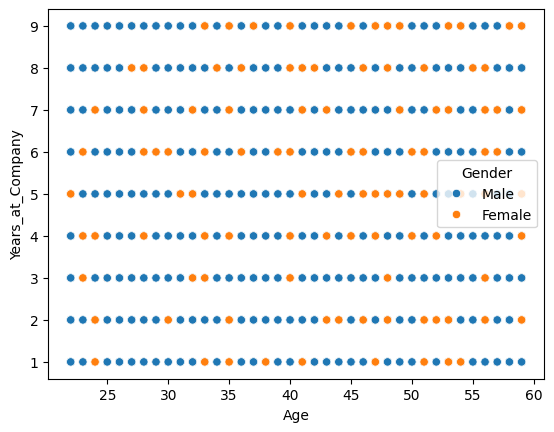

In [226]:
sns.scatterplot(data = df, x = 'Age',y ='Years_at_Company',hue='Gender')
plt.show()

<Axes: xlabel='Marital_Status', ylabel='Years_at_Company'>

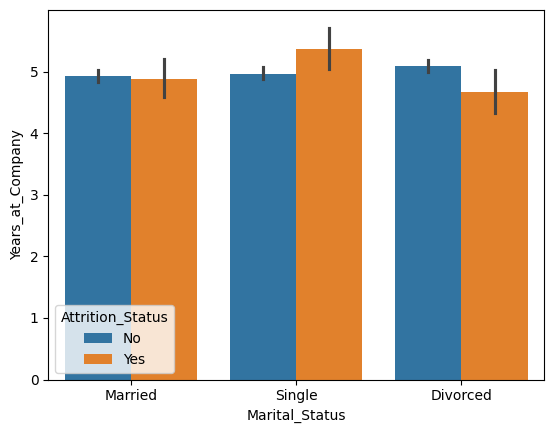

In [227]:
sns.barplot(data= df, x = 'Marital_Status', y = 'Years_at_Company', hue = 'Attrition_Status')

<Axes: xlabel='Marital_Status', ylabel='Annual_Income'>

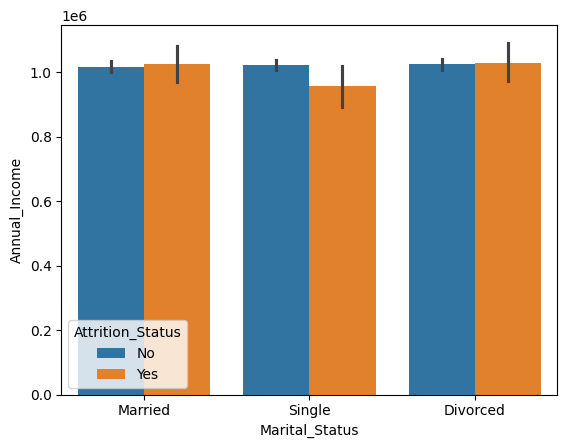

In [228]:
sns.barplot(data= df, x = 'Marital_Status', y = 'Annual_Income', hue = 'Attrition_Status')

<Axes: xlabel='Gender', ylabel='Annual_Income'>

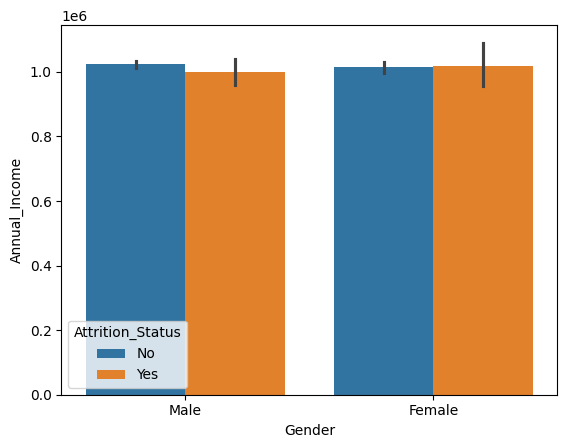

In [229]:
sns.barplot(data= df, x = 'Gender', y = 'Annual_Income', hue = 'Attrition_Status')

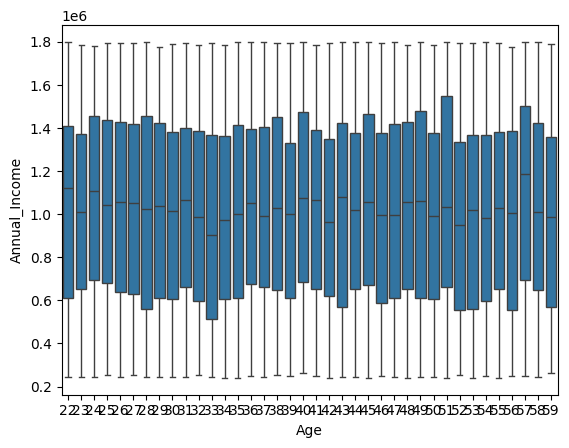

In [230]:
sns.boxplot(data=df,x='Age',y='Annual_Income')
plt.show()

Train Test Split
* 7:3

In [231]:
x = df.iloc[:, :-1]
y = df['Attrition_Status']

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    train_size= 0.65,
    random_state=42,
    stratify=y

)

l_encoder = LabelEncoder()
y_train_encoded = l_encoder.fit_transform(y_train)
y_test_encoded = l_encoder.transform(y_test)



Understanding Distribution of numerical columns
* can be done either after encoding or before encoding

In [232]:
num_columns = x_train.select_dtypes(int).columns.tolist()
num_columns



['Age', 'Years_at_Company', 'Annual_Income', 'Employee_Cost_to_Company']

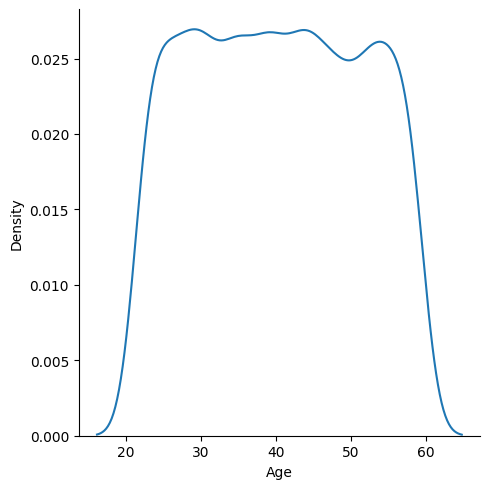

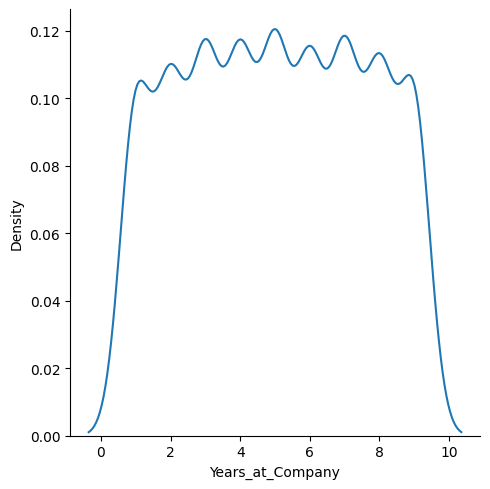

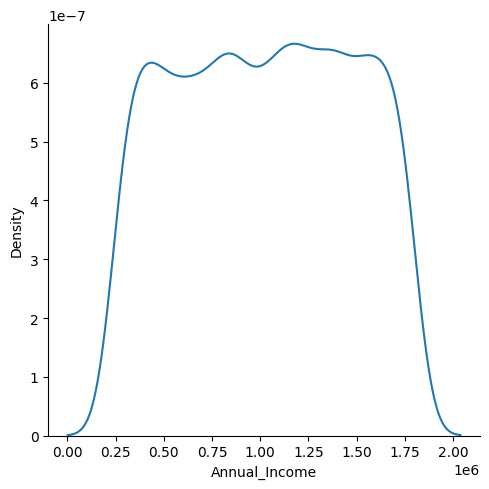

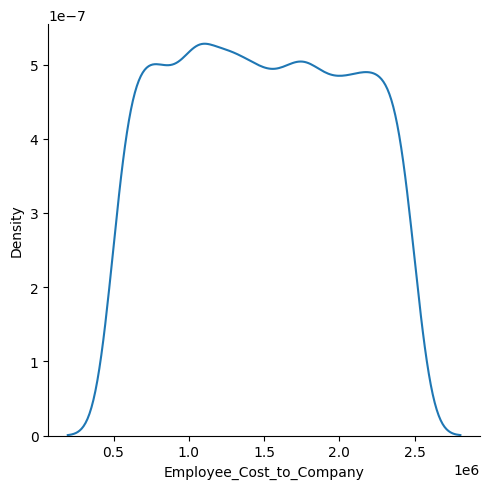

In [233]:

for cols in num_columns:
    sns.displot(data = x_train, x = cols,kind='kde')
    plt.show()

In [234]:
skew = x_train[num_columns].skew()
skew

Age                         0.021017
Years_at_Company           -0.007110
Annual_Income              -0.023561
Employee_Cost_to_Company    0.027183
dtype: float64

all 4 columns are approximatly symmetric, so dont need to apply transformers
* for for comparison lets apply transformers

In [235]:
df['Employment_Type'].value_counts()

Employment_Type
Full-time    7171
Part-time     929
Contract      900
Name: count, dtype: int64

Separate Pipelines
* numerical pipeline(with transformation)
* numerical pipeline(without transformation)
* ordinal pipeline
* nominal pipeline

**Numerical Pipeline and scaling pipeline**

* Impute( not required here )
* transform( required for experimentation and only for Annual_Income, Employee_Cost_to_Company)
* scale

In [236]:
numerical_pipeline = Pipeline([
    ('transfromer',PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

numerical_only_scaling_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

Age ────────────────────────→ Scaling
Years_at_Company ───────────→ Scaling

Annual_Income ───────────────→ Yeo-Johnson → Scaling
Employee_Cost_to_Company ────→ Yeo-Johnson → Scaling

* Create scaling and transfrom-scale 

In [237]:
transform_column = skew[skew < 0].index.tolist()
normal_numerical_column = [col for col in num_columns if col not in transform_column]

Column Transformer for transforming scaling specific columns

In [238]:
numerical_preprocessor_transformed = ColumnTransformer(
    transformers=[
        ('transformer', numerical_pipeline, transform_column),
        ('scaling', numerical_only_scaling_pipeline, normal_numerical_column)
    ],
    remainder='passthrough'
)

numerical_preprocessor_no_transform = ColumnTransformer(
    transformers=[
        ('scaling',numerical_only_scaling_pipeline,num_columns)
    ],
    remainder='passthrough'
)

In [239]:
cat_columns = x_train.select_dtypes(include=['object', 'category']).columns.tolist()

ordinal_columns = ['Environment_Satisfaction', 'Education_Level', 'Employment_Type']
nominal_columns = [col for col in cat_columns if col not in ordinal_columns]

**categorical Pipeline**
nominal pipeline
ordinal pipeline
label encoder

In [240]:
nominal_pipeline = Pipeline([
    ('nominal_encoding', OneHotEncoder(
        drop='first', 
        sparse_output=False, 
        dtype='int32',
        handle_unknown='ignore'
    ))
])

ordinal_pipeline = Pipeline([
    ('ordinal_encoding', OrdinalEncoder(
        categories=[
            ['Low', 'Medium', 'High', 'VeryHigh'],
            ['High School', 'Diploma', 'Graduate', 'Postgraduate', 'PhD'],
            ['Contract', 'Part-time', 'Full-time']
        ],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

**Categorical Preprocessor**

In [241]:
categorical_preprocessor = ColumnTransformer(
    transformers=[
        ('nominal',nominal_pipeline,nominal_columns),
        ('ordinal',ordinal_pipeline,ordinal_columns),
    
    ],
    remainder='passthrough'
)

**Master processor**

In [242]:
# Master preprocessor merging your numerical and categorical components
final_preprocessor = ColumnTransformer(
    transformers=[
        ('num_block', numerical_preprocessor_transformed, transform_column + normal_numerical_column),
        #('num_block', numerical_preprocessor_no_transform,num_columns),
        ('cat_block', categorical_preprocessor, nominal_columns + ordinal_columns)
    ],
    remainder='drop'
)

Final Pipeline

In [243]:
log_reg_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Fit on training data
log_reg_pipeline.fit(x_train, y_train_encoded)




,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_block', ...), ('cat_block', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Exporting logistic regression pipeline**

In [244]:
import joblib

# ✅ Pass the variable directly (NO quotes around model_pipeline)
joblib.dump(log_reg_pipeline, "log_reg_pipeline.joblib")

['log_reg_pipeline.joblib']

 **Predict on unseen test data** 


In [245]:
y_pred_encoded = log_reg_pipeline.predict(x_test)

# Accuracy & Metrics
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"Test Accuracy: {accuracy * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test_encoded, y_pred_encoded, target_names=l_encoder.classes_))

labels =['no','yes']
cm = confusion_matrix(y_test_encoded, y_pred_encoded)
cm_df = pd.DataFrame(
    cm,
    index = [f"Actual{label}" for label in labels],
    columns = [f"predicted{label}" for label in labels]
)
print("--- Confusion Matrix ---")
print(cm_df)

Test Accuracy: 53.14%

--- Classification Report ---
              precision    recall  f1-score   support

          No       0.93      0.54      0.68      2921
         Yes       0.08      0.48      0.13       229

    accuracy                           0.53      3150
   macro avg       0.50      0.51      0.41      3150
weighted avg       0.87      0.53      0.64      3150

--- Confusion Matrix ---
           predictedno  predictedyes
Actualno          1563          1358
Actualyes          118           111


* Support Count - actual count of samples for each class in test dataset
* precision - when modal predicts, how accurate it is
* recall(sensitivity) - Out of 2504 no cases, model caught all 2504 so 1.00, for yes out of 196 model caught 0.
* harmonic mean of precision and recall. 0 to 1( worst to best )

**model underfitted with biased predictions**



**Train vs. Test Performance**
* ROC AUC measures classificaions models's ability to distinguish between classes across all possible decision classes across all possible decision thresholds
* has ROC curve on true positive and false positive
* 0 to 1, 1 - perfect classification and separate between classes
* 0.5 - like a coin flip
* <0.5 - worst then coin flip

In [246]:
from sklearn.metrics import roc_auc_score

# Training evaluation
train_preds = log_reg_pipeline.predict(x_train)
train_proba = log_reg_pipeline.predict_proba(x_train)[:, 1]

# Test evaluation
test_preds = log_reg_pipeline.predict(x_test)
test_proba = log_reg_pipeline.predict_proba(x_test)[:, 1]

print("--- TRAIN PERFORMANCE ---")
print(f"Train Accuracy: {accuracy_score(y_train_encoded, train_preds) * 100:.2f}%")
print(f"Train ROC-AUC:  {roc_auc_score(y_train_encoded, train_proba):.4f}")

print("\n--- TEST PERFORMANCE ---")
print(f"Test Accuracy:  {accuracy_score(y_test_encoded, test_preds) * 100:.2f}%")
print(f"Test ROC-AUC:   {roc_auc_score(y_test_encoded, test_proba):.4f}")

--- TRAIN PERFORMANCE ---
Train Accuracy: 55.15%
Train ROC-AUC:  0.5886

--- TEST PERFORMANCE ---
Test Accuracy:  53.14%
Test ROC-AUC:   0.5062


if test and train accuracy is approx 50 %, model cannot have class separation( not st line)

**Clustering**
Finding optimal path

In [247]:
WCSS = []
x_preprocessed = final_preprocessor.fit_transform(x_train)

# Should be scaled,transofrmed, encoded before passing to clustering #
k_range = range(1,11)
for i in k_range:
    km = KMeans(n_clusters = i, random_state=42)
    km.fit(x_preprocessed)
    WCSS.append(km.inertia_)
    print(f"clusters(K) = {i} | Inertia(WCSS) = {km.inertia_:.2f}")

clusters(K) = 1 | Inertia(WCSS) = 65599.10
clusters(K) = 2 | Inertia(WCSS) = 56914.34
clusters(K) = 3 | Inertia(WCSS) = 53208.64
clusters(K) = 4 | Inertia(WCSS) = 51923.82
clusters(K) = 5 | Inertia(WCSS) = 49926.92
clusters(K) = 6 | Inertia(WCSS) = 48191.70
clusters(K) = 7 | Inertia(WCSS) = 47137.23
clusters(K) = 8 | Inertia(WCSS) = 46059.34
clusters(K) = 9 | Inertia(WCSS) = 45259.30
clusters(K) = 10 | Inertia(WCSS) = 44611.48


AttributeError: module 'matplotlib.pyplot' has no attribute 'x_label'

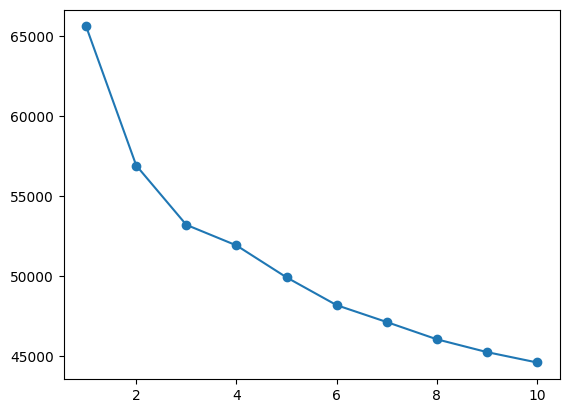

In [248]:
plt.plot(k_range,WCSS,marker = 'o')
plt.x_label('clusters')
plt.y_label('Inertia')

After 4, curve is linearly decreasing so optimal is either 3 or 4

In [ ]:
from sklearn.metrics import silhouette_score

for i in range(2,6):
    km = KMeans(n_clusters=i,random_state=42,n_init='auto')
    labels = km.fit_predict(x_preprocessed)
    score = silhouette_score(x_preprocessed, labels)
    print(f"K = {i} | Silhouette Score = {score:.4f}")



K = 2 | Silhouette Score = 0.1217
K = 3 | Silhouette Score = 0.0956
K = 4 | Silhouette Score = 0.0792
K = 5 | Silhouette Score = 0.0701


Clustering pipeline

In [ ]:
optimal_k = 3
clustering_pipeline = Pipeline([
    ('final_preprocessor',final_preprocessor),
    ('clustering_model',KMeans(n_clusters=optimal_k,random_state=42,n_init='auto'))
])

clustering_pipeline.fit(x_train)
joblib.dump('clustering_pipeline','clustering_pipeline.joblib')


['clustering_pipeline.joblib']

In [ ]:
x_train.loc[25]

Gender                          Female
Age                                 44
Years_at_Company                     2
Annual_Income                   516216
Department                     Finance
Job_Role                    Technician
Position                        Senior
Employment_Type              Full-time
State                       Tamil Nadu
Education_Level                Diploma
Marital_Status                Divorced
Environment_Satisfaction     Very High
Employee_Cost_to_Company       2303164
Name: 25, dtype: object